In [34]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
)

In [35]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC=0.0, t_1=-1, lambda_SOC=0.0):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["onsite_energy"][label_i]["E_s"] = -5
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.01 * np.abs(t_1)
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1/2
            except:
                pass
            try:
                parser["kane_mele_soc"][label_j]["lambda_pp"] = lambda_SOC
            except:
                pass
        # print(parser)   
set_eigenvalues(problem, 0.0, -1, -0.)

In [36]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [37]:

problem.cell_parser.eigenvalues.B.value

{'onsite_energy': {'B': {'E_s': -5, 'E_p': 0}},
 'nn_hopping': {'A': {'t_ss_sigma': np.float64(0.01),
   't_sp_sigma': 0,
   't_pp_sigma': -1,
   't_pp_pi': -0.5},
  'C': {'t_ss_sigma': np.float64(0.01),
   't_sp_sigma': 0,
   't_pp_sigma': -1,
   't_pp_pi': -0.5}},
 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': -0.0},
  'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': -0.0},
  'C': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': -0.0}},
 'chadi_soc': {'B': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': 0.0}},
 'interaction': {'B': {'U_s': 0,
   'U_p': 0,
   'n_s_up': 0,
   'n_s_down': 0,
   'n_px_up': 0,
   'n_px_down': 0,
   'n_py_up': 0,
   'n_py_down': 0,
   'n_pz_up': 0,
   'n_pz_down': 0}}}

In [38]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]

In [39]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...


'Bulk' Eigenvalues - Done!


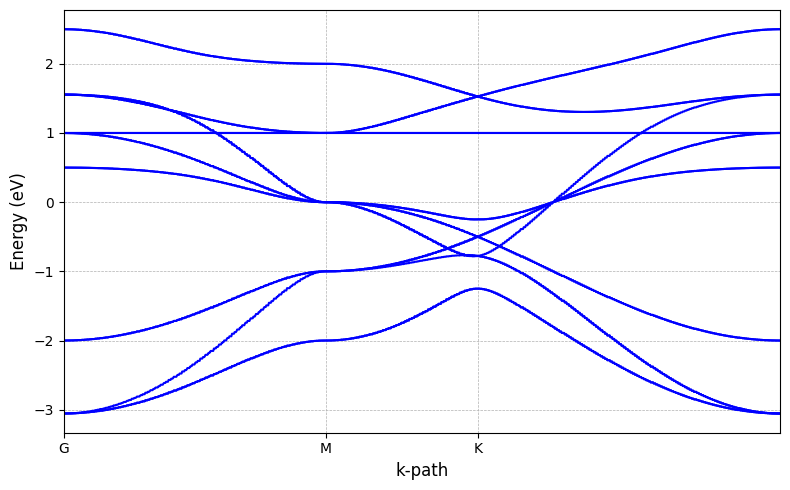

: 

In [ ]:
tb_bulk.plot_band_structure(g, bands = [i for i in range(7, 24)])